<a href="https://colab.research.google.com/github/HERO-DS/Computational-Drug-Discovery-LRRK2-gene/blob/main/CDD_ML_Part_4_LRRK2_Regression_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regression Models with Random Forest**

building a regression model of LRRK2 inhibitors using the random forest algorithm.

## **1. Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## **2. Load the data set**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load your prepared LRRK2 dataset from Part 3
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/LRRK2_06_bioactivity_data_3class_pIC50_ecfp4.csv')
df.head()

Mounted at /content/drive


,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,pIC50
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.879426
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.387216
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,7.795880
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,7.886057
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,8.107905


## **3. Input features**
The ***LRRK2*** data set contains 1024 input features and 1 output variable (pIC50 values).

### **3.1. Input features**

In [ ]:
# X: 1024 ECFP4 fingerprint columns
X = df.drop('pIC50', axis=1)
X


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
3779,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3780,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3781,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### **3.2. Output features**

In [ ]:
# Y: pIC50 target column
Y = df['pIC50']
Y

,pIC50
0,4.879426
1,5.387216
2,7.795880
3,7.886057
4,8.107905
...,...
3778,6.080922
3779,7.091515
3780,8.221849
3781,8.221849


### **3.3. Let's examine the data dimension**

In [ ]:
X.shape

(3783, 1024)

In [ ]:
Y.shape

(3783,)

## **4. Data split (80/20 ratio)**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [ ]:
X_train.shape, Y_train.shape

((3026, 1024), (3026,))

In [ ]:
X_test.shape, Y_test.shape

((757, 1024), (757,))

## **5. Building a Regression Model using Random Forest**

In [ ]:
# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")

R² Score: 0.7191
RMSE:     0.5229


## **6. Scatter Plot of Experimental vs Predicted pIC50 Values**

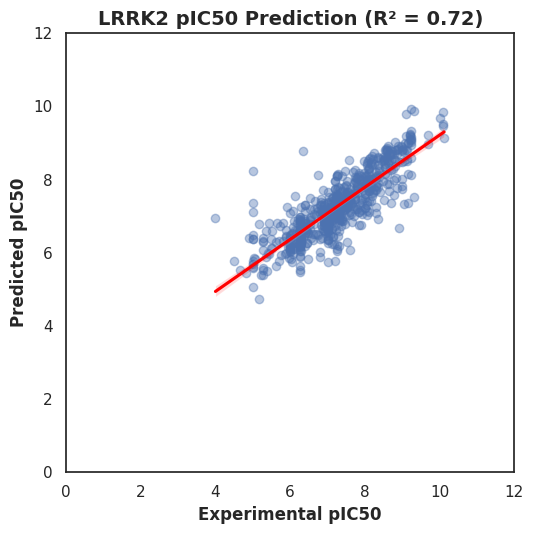

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(5.5, 5.5))

# Plot regression scatter plot (explicitly defining x and y to avoid Seaborn warnings)
ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
ax.set_xlabel('Experimental pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

plt.title(f'LRRK2 pIC50 Prediction (R² = {r2:.2f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()  # Call as a function with ()